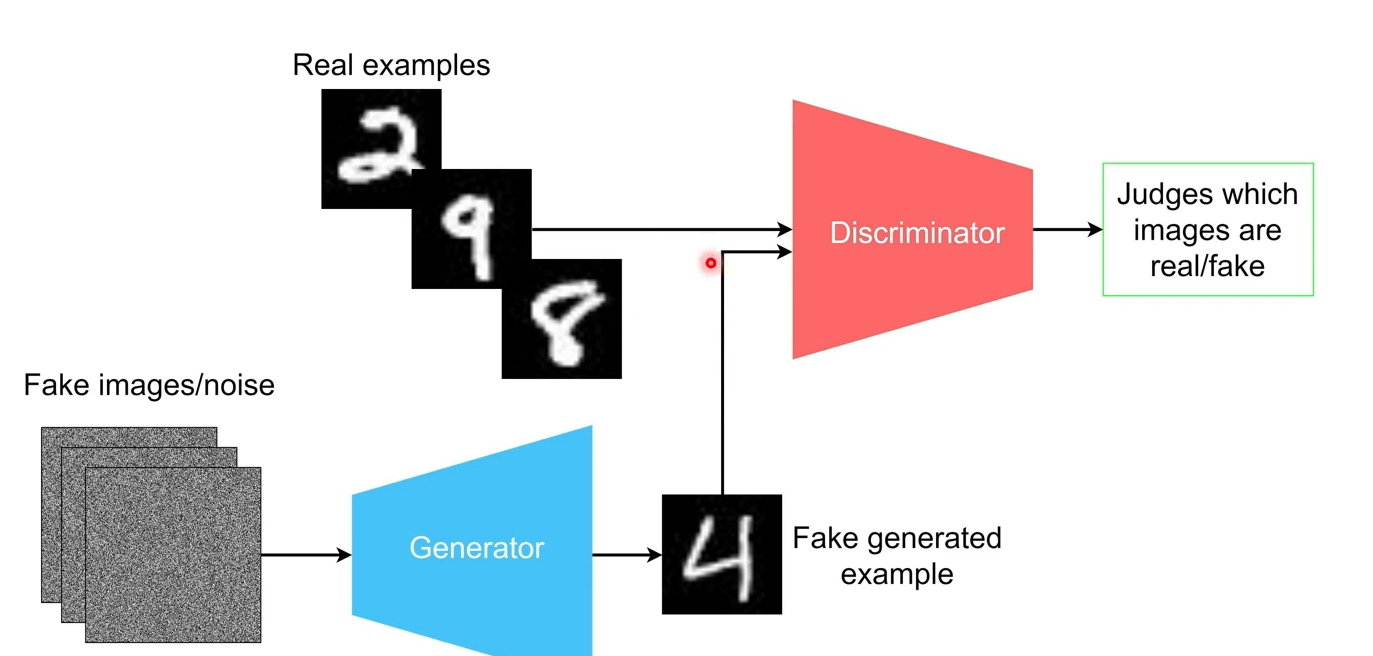

In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.utils as utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [89]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [90]:
batch_size = 64
image_size = 28*28

In [91]:
transform = transforms.Compose(
    [    
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,)) # [-1,1]
    ]
)

In [92]:
dataset = datasets.MNIST(root= "./data", train=True, transform=transform, download=True)

data_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

In [93]:
print(len(data_loader))
print(len(dataset))

938
60000


In [94]:
class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator,self).__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=image_size, out_features=1024), #1024 neurons
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(in_features=1024, out_features=512),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(in_features=256, out_features=1),
            nn.Sigmoid()  #retun 0 or 1
        )

    def forward(self, img):
        return self.model(img.view(-1, image_size)) # image_size = 28*28




In [95]:
class Generator(nn.Module):

    def __init__(self, z_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(in_features=z_dim, out_features=256),
            nn.LeakyReLU(0.2),
            nn.Linear(in_features=256, out_features=512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, out_features=image_size),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x).view(-1, 1, 28, 28)

In [96]:
learning_rate = 0.0002
z_dim = 100
epochs = 35

In [97]:
generator = Generator(z_dim=z_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(),     lr=learning_rate, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))  


In [98]:
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(data_loader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)
        real_labels = torch.ones(batch_size, 1).to(device) # label 1 for real images
        fake_labels = torch.zeros(batch_size, 1).to(device) # label 0 for fake images

        #Discriminator training
        d_optimizer.zero_grad() # reset gradiant
        z = torch.randn(batch_size, z_dim).to(device) #random noice
        fake_img = generator(z)
        real_loss = criterion(discriminator(real_imgs), real_labels) 
        fake_loss = criterion(discriminator(fake_img.detach()), fake_labels)
        d_loss = real_loss + fake_loss

        
        d_loss.backward()
        d_optimizer.step()


        #Generator training
        g_loss = criterion(discriminator(fake_img), real_labels)
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch: {epoch+1}/{epochs}, d_loss: {d_loss.item():.3f}, g_loss: {g_loss.item():.3f}")

Epoch: 1/35, d_loss: 0.476, g_loss: 2.743
Epoch: 2/35, d_loss: 0.392, g_loss: 1.570
Epoch: 3/35, d_loss: 0.480, g_loss: 2.824
Epoch: 4/35, d_loss: 0.561, g_loss: 2.537
Epoch: 5/35, d_loss: 0.829, g_loss: 1.006
Epoch: 6/35, d_loss: 0.944, g_loss: 1.220
Epoch: 7/35, d_loss: 0.719, g_loss: 1.512
Epoch: 8/35, d_loss: 0.690, g_loss: 1.791
Epoch: 9/35, d_loss: 0.811, g_loss: 0.985
Epoch: 10/35, d_loss: 0.705, g_loss: 2.984
Epoch: 11/35, d_loss: 0.743, g_loss: 1.727
Epoch: 12/35, d_loss: 0.655, g_loss: 1.867
Epoch: 13/35, d_loss: 1.076, g_loss: 1.890
Epoch: 14/35, d_loss: 0.859, g_loss: 1.914
Epoch: 15/35, d_loss: 0.792, g_loss: 2.646
Epoch: 16/35, d_loss: 1.086, g_loss: 0.994
Epoch: 17/35, d_loss: 0.661, g_loss: 2.608
Epoch: 18/35, d_loss: 0.757, g_loss: 1.857
Epoch: 19/35, d_loss: 0.869, g_loss: 1.145
Epoch: 20/35, d_loss: 0.728, g_loss: 1.955
Epoch: 21/35, d_loss: 0.876, g_loss: 1.439
Epoch: 22/35, d_loss: 0.924, g_loss: 2.663
Epoch: 23/35, d_loss: 0.773, g_loss: 1.943
Epoch: 24/35, d_loss

In [99]:
num_test_img = 16

In [100]:
with torch.no_grad():
    test_noise = torch.randn(num_test_img, z_dim).to(device)
    generated_imgs = generator(test_noise).cpu()
    grid = np.transpose(utils.make_grid(generated_imgs, nrow=4, normalize=True), (1,2,0))

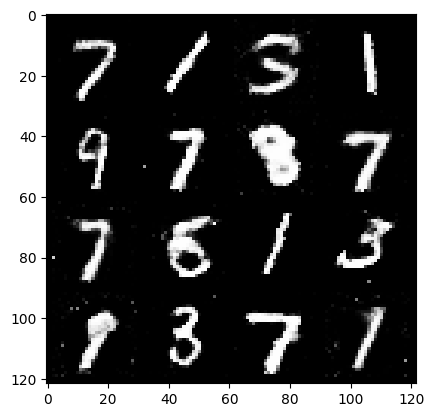

In [101]:
plt.imshow(grid)
plt.show()